# Raw metrics visualization across all model training condition and inference condition
Might need refactor the dataframe wrangling to lazy as we only visualize a metric at a time


In [1]:
import pathlib
import sys
import warnings
import yaml

import polars as pl

utils_path = pathlib.Path('.') / 'src'
sys.path.append(str(utils_path))
from vs_eval_utils.visualization import plot_cm_raw_metrics # type: ignore

## Pathing

In [2]:
PLOT_DIR = pathlib.Path('./plots/')
PLOT_DIR.mkdir(exist_ok=True)
PLOT_SUBDIR = PLOT_DIR / "raw_metrics"
PLOT_SUBDIR.mkdir(exist_ok=True)

EVAL_DIR = pathlib.Path('/mnt/hdd20tb/vsf_eval2/')
ENRICHED_EVAL_PARQUET = EVAL_DIR / "eval_enriched_merged.parquet"
if not ENRICHED_EVAL_PARQUET.exists():
    raise FileNotFoundError(f"Enriched evaluation parquet file not found at {ENRICHED_EVAL_PARQUET}. Please run the enrichment notebook to generate it.")

CELL_PAL = EVAL_DIR / "cell_palette.yaml"
if not CELL_PAL.exists():
    raise FileNotFoundError(f"Cell palette file not found at {CELL_PAL}. Please ensure the file exists.")
ARCHITECTURE_PAL = EVAL_DIR / "architecture_palette.yaml"
if not ARCHITECTURE_PAL.exists():
    raise FileNotFoundError(f"Architecture palette file not found at {ARCHITECTURE_PAL}. Please ensure the file exists.")
CHANNEL_PAL = EVAL_DIR / "channel_palette.yaml"
if not CHANNEL_PAL.exists():
    raise FileNotFoundError(f"Channel palette file not found at {CHANNEL_PAL}. Please ensure the file exists.")
DENSITY_PAL = EVAL_DIR / "density_palette.yaml"
if not DENSITY_PAL.exists():
    raise FileNotFoundError(f"Density palette file not found at {DENSITY_PAL}. Please ensure the file exists.")

In [3]:
eval_df = pl.read_parquet(ENRICHED_EVAL_PARQUET).to_pandas()

In [4]:
with open(CELL_PAL) as file:
    cell_palette = yaml.safe_load(file)
with open(ARCHITECTURE_PAL) as file:
    architecture_palette = yaml.safe_load(file)
with open(CHANNEL_PAL) as file:
    channel_palette = yaml.safe_load(file)
with open(DENSITY_PAL) as file:
    density_palette = yaml.safe_load(file)

## Define metric specific transforms to apply to some metrics to get all metrics to higher=better

In [5]:

def transform_dists(x):
    # 1 - dists because higher is better for visualization purposes
    return 1 - x

def transform_unbounded(x):
    return - x

# apply transformations such that all metrics are higher is better
model_eval_dict = {
    "dists": {
        "name": "1-DISTS",
        "transform_fn": transform_dists
    },
    "lpips": {
        "name": "LPIPS",
        "transform_fn": None
    },
    "mae": {
        "name": "-MAE",
        "transform_fn": transform_unbounded
    },
    "ssim": {
        "name": "SSIM",
        "transform_fn": None
    },
    "foreground_ssim": {
        "name": "fore-SSIM",
        "transform_fn": None,
    },
    # also save for later due to inf values
    # "psnr": {
    #     "name": "PSNR",
    #     "transform_fn": None
    # },
    # "foreground_psnr": {
    #     "name": "fore-PSNR",
    #     "transform_fn": None
    # },
}

Plotting metric: dists


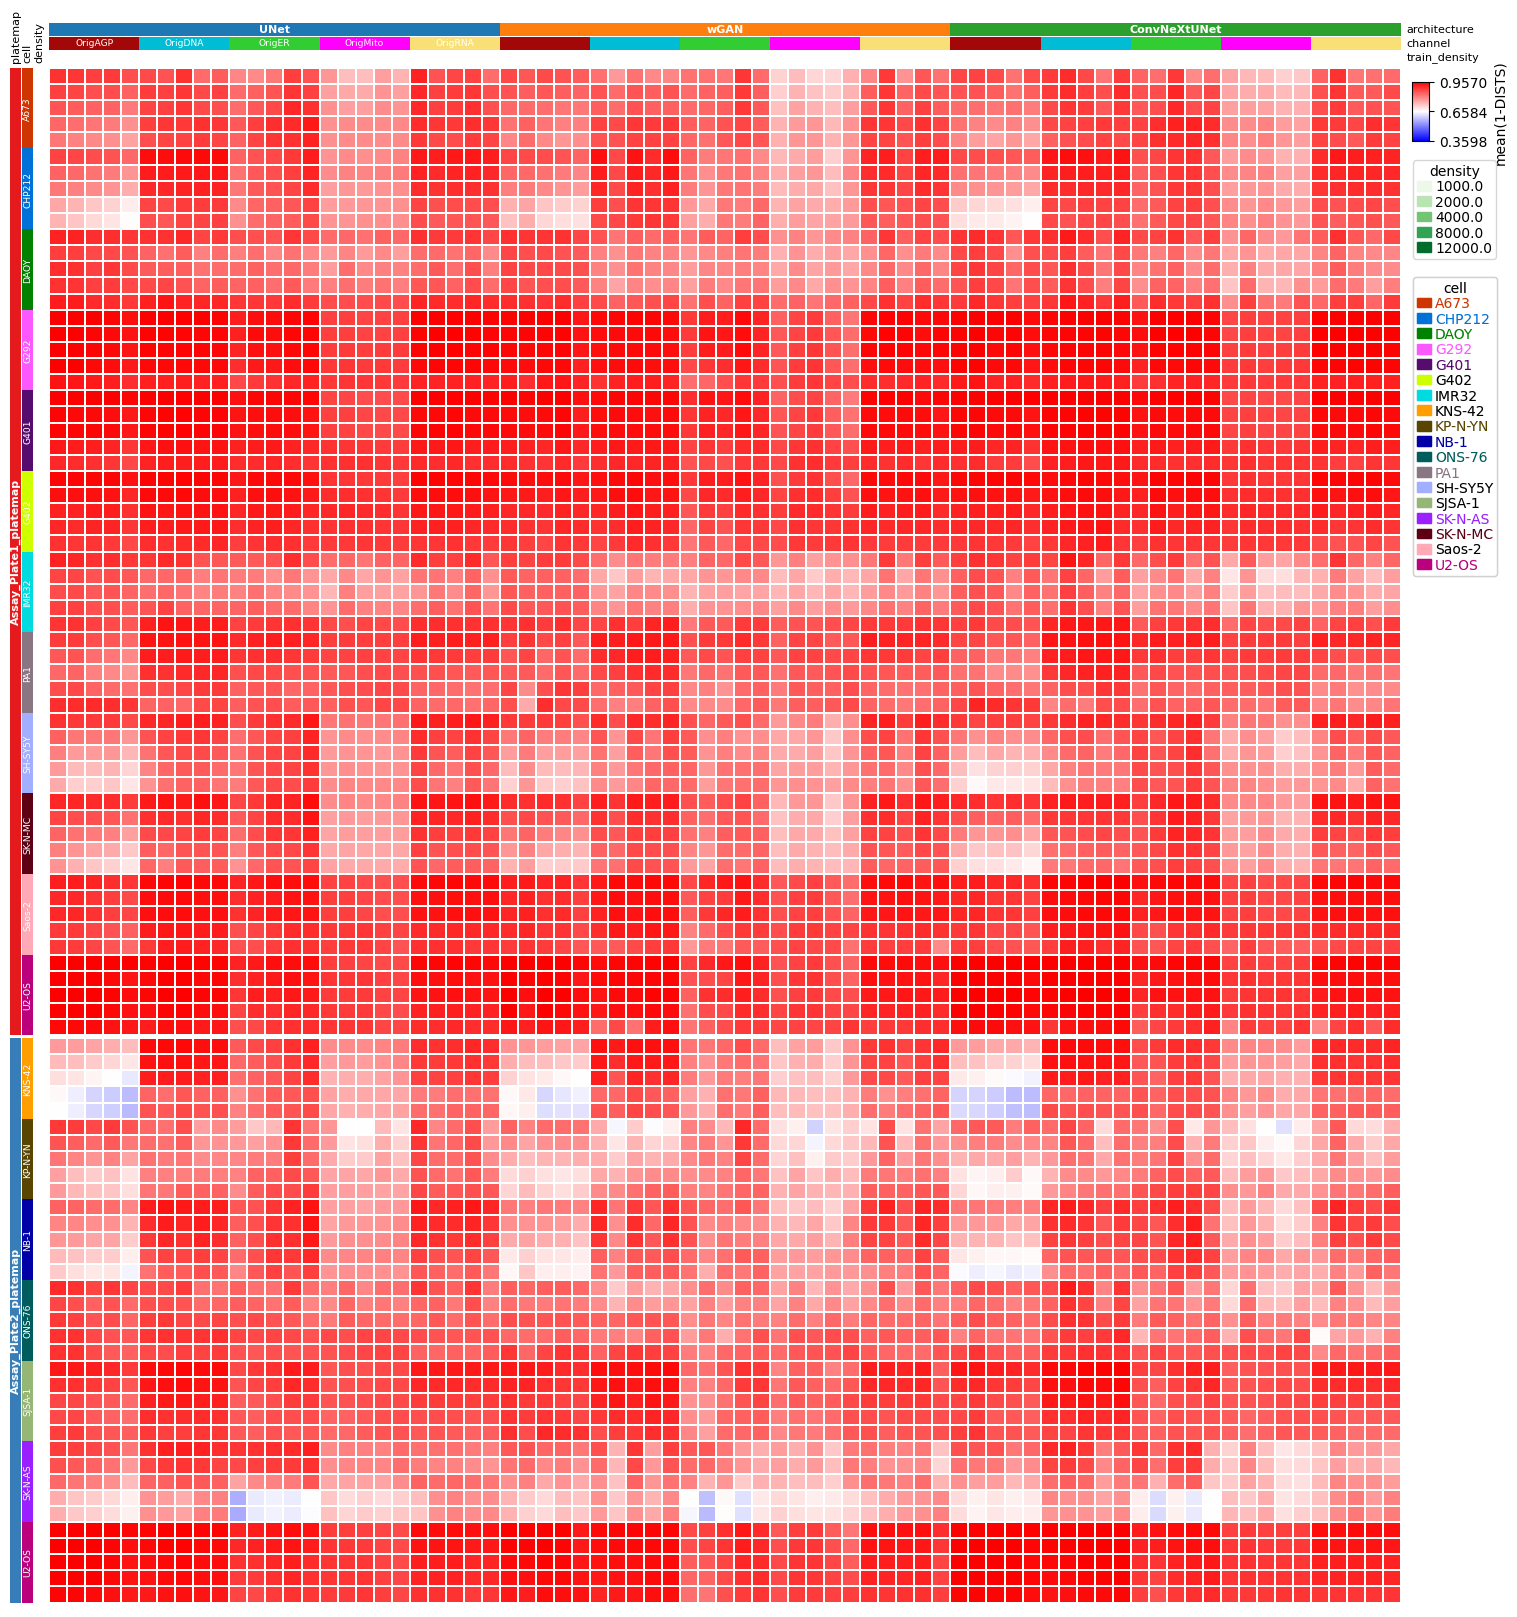

Plotting metric: lpips


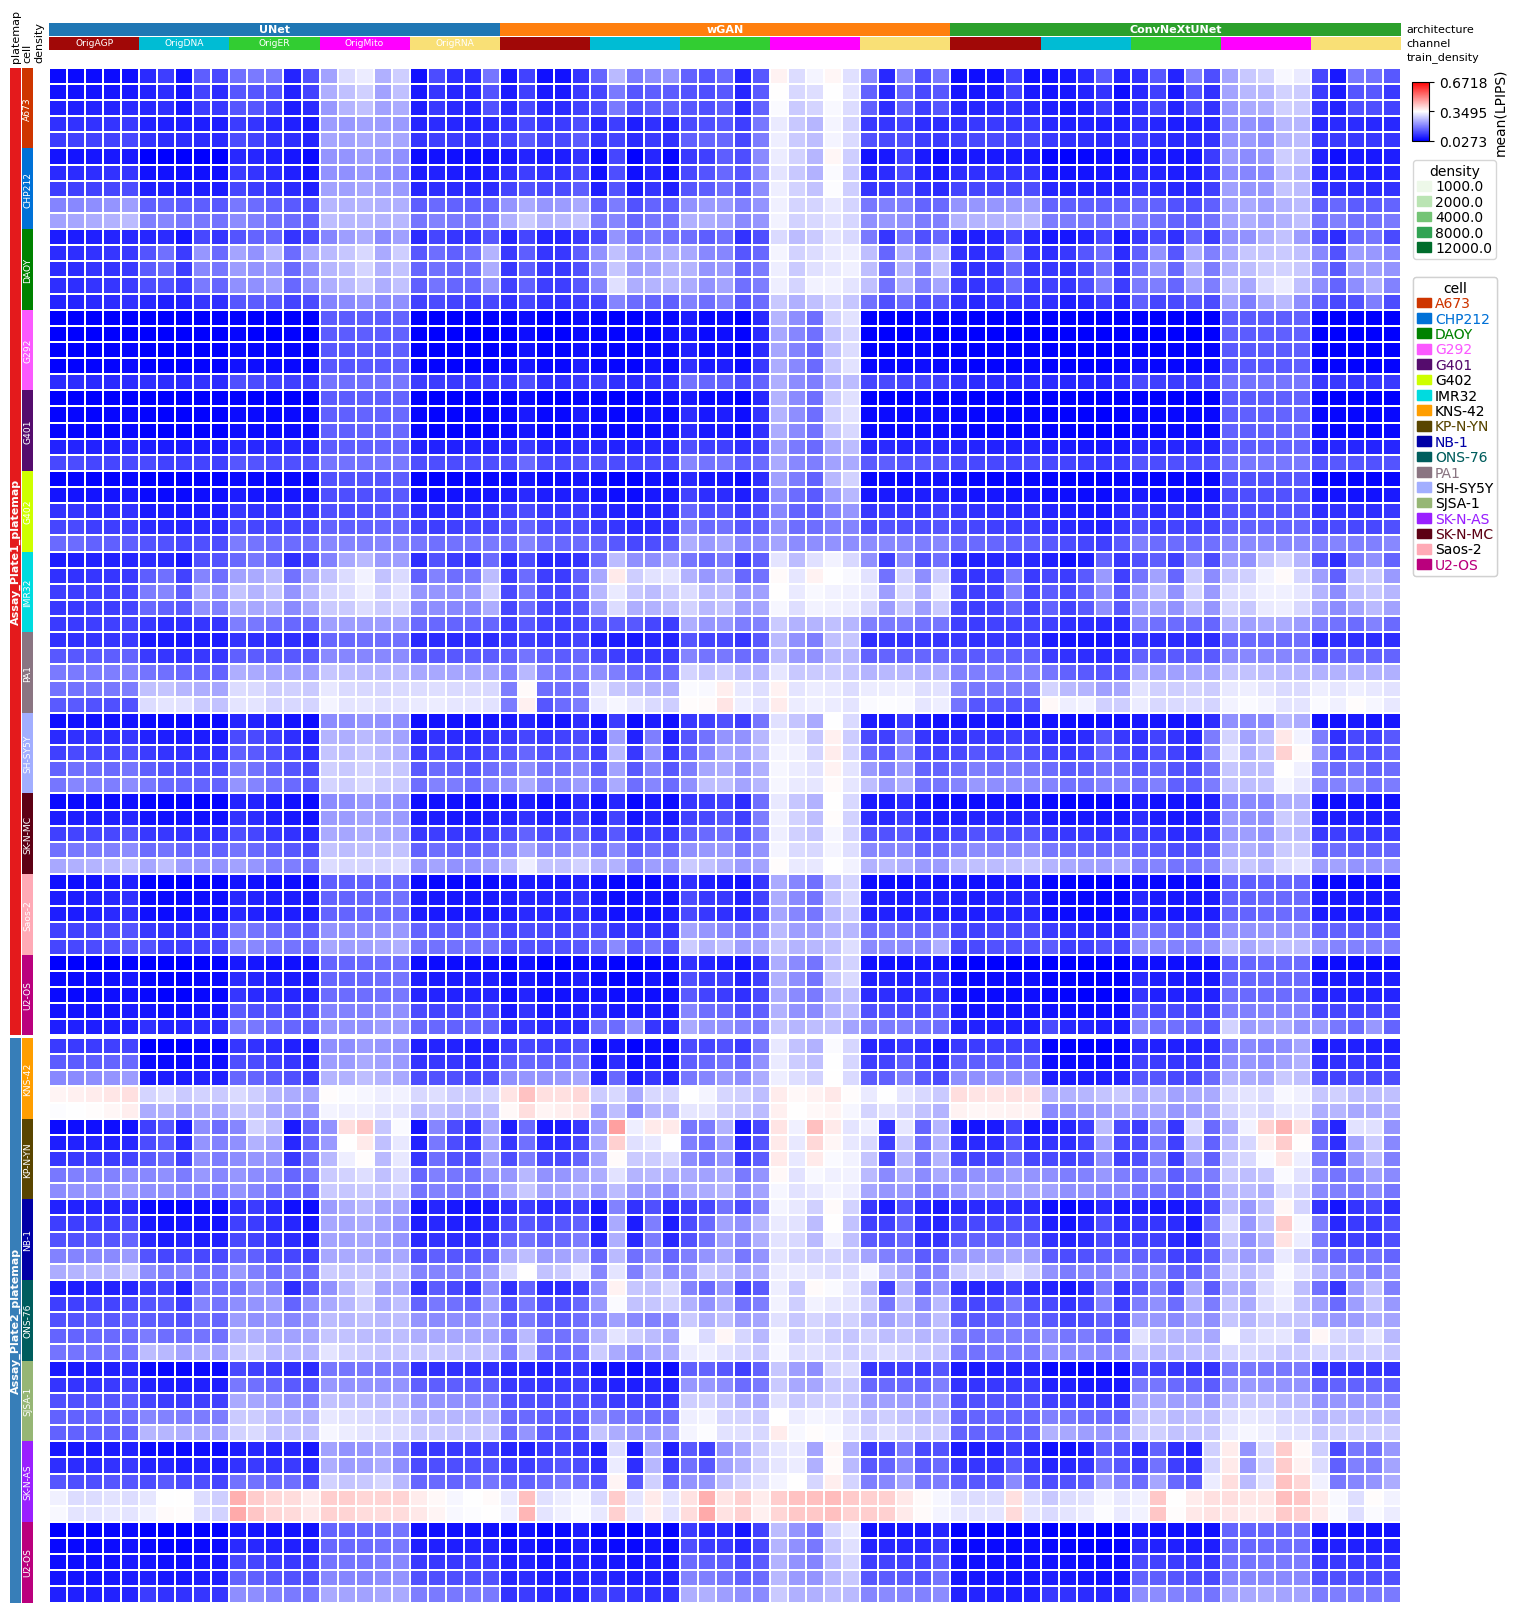

Plotting metric: mae


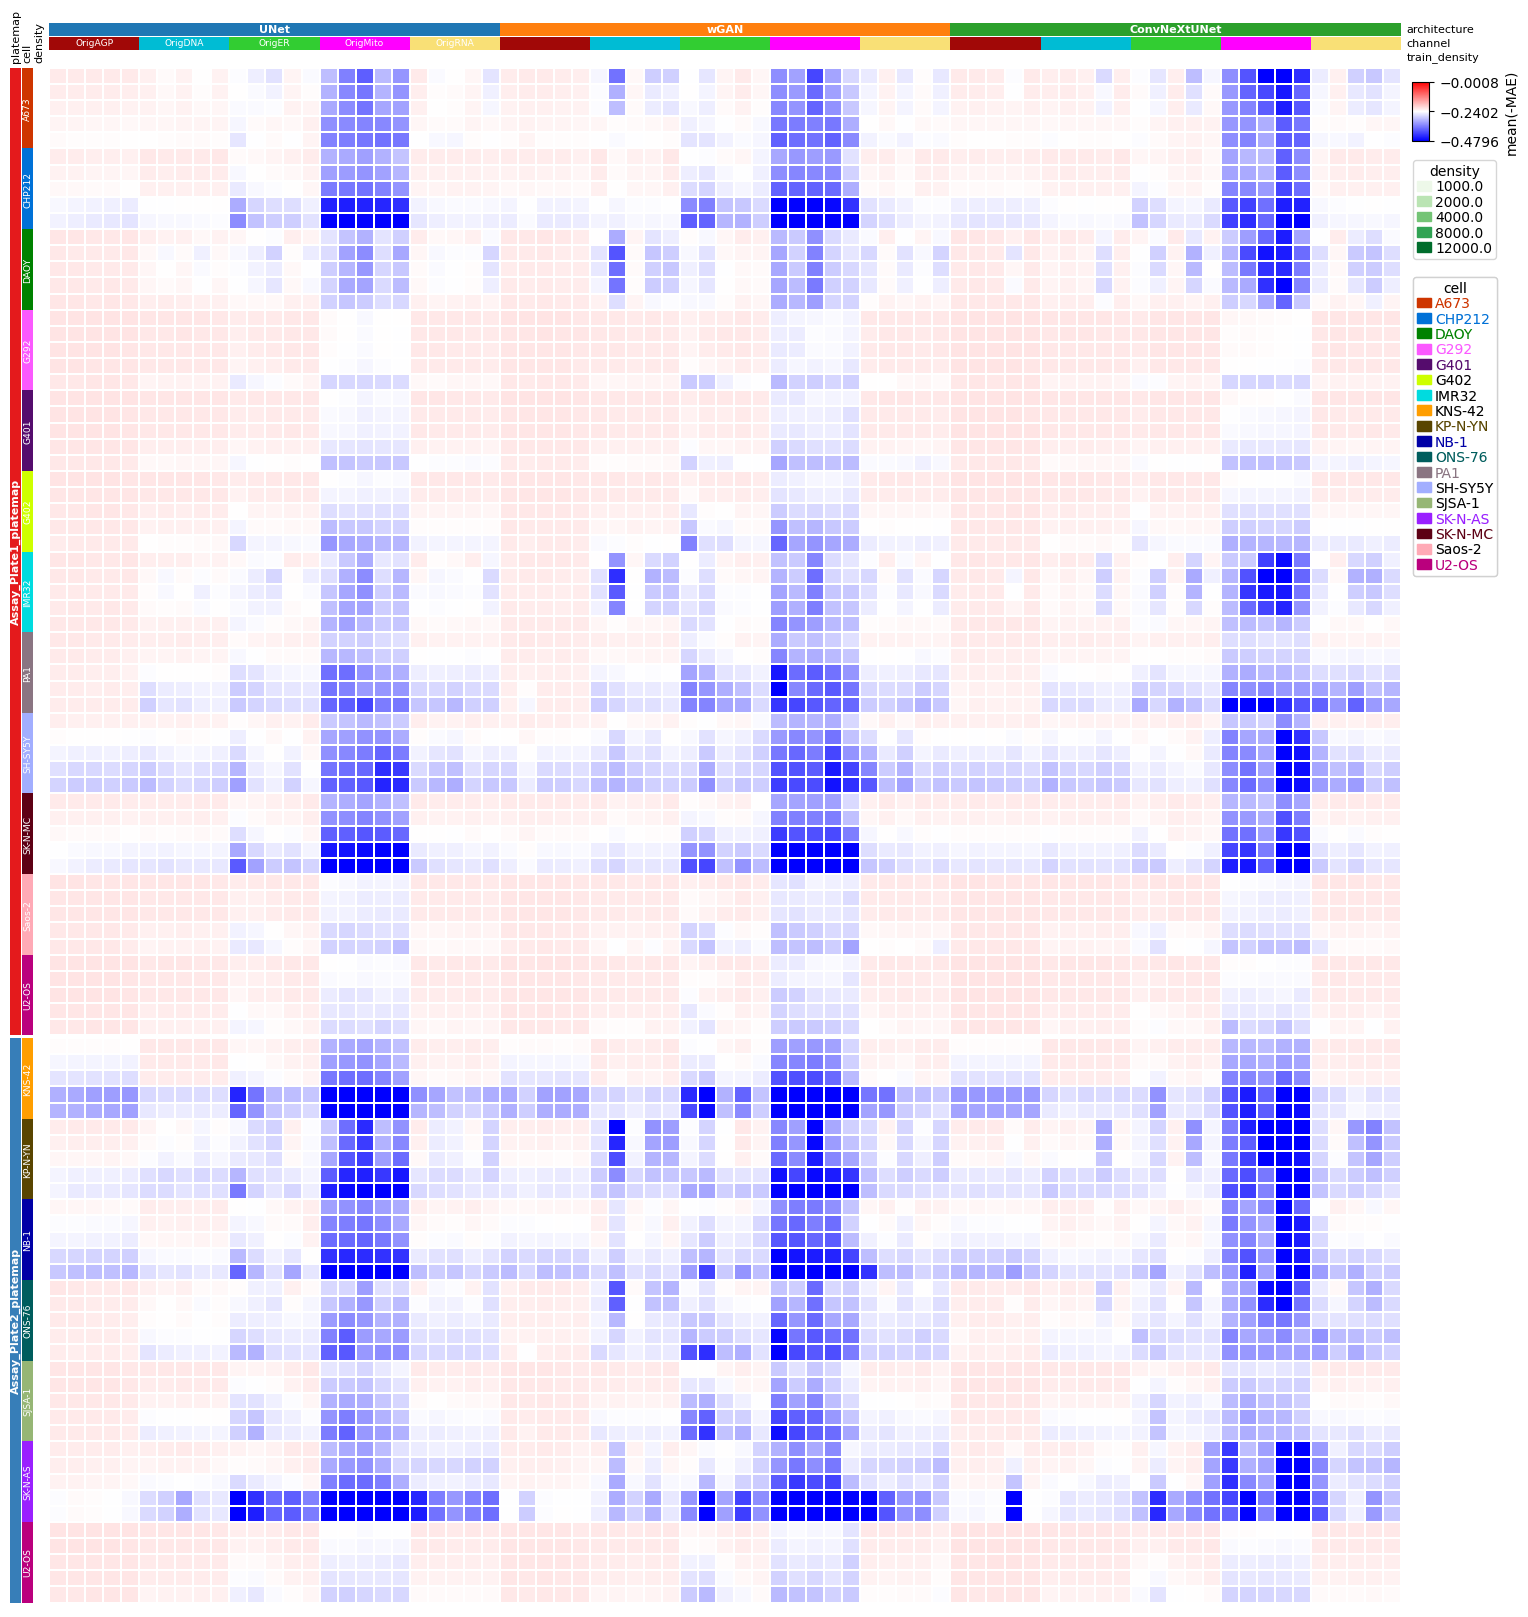

Plotting metric: ssim


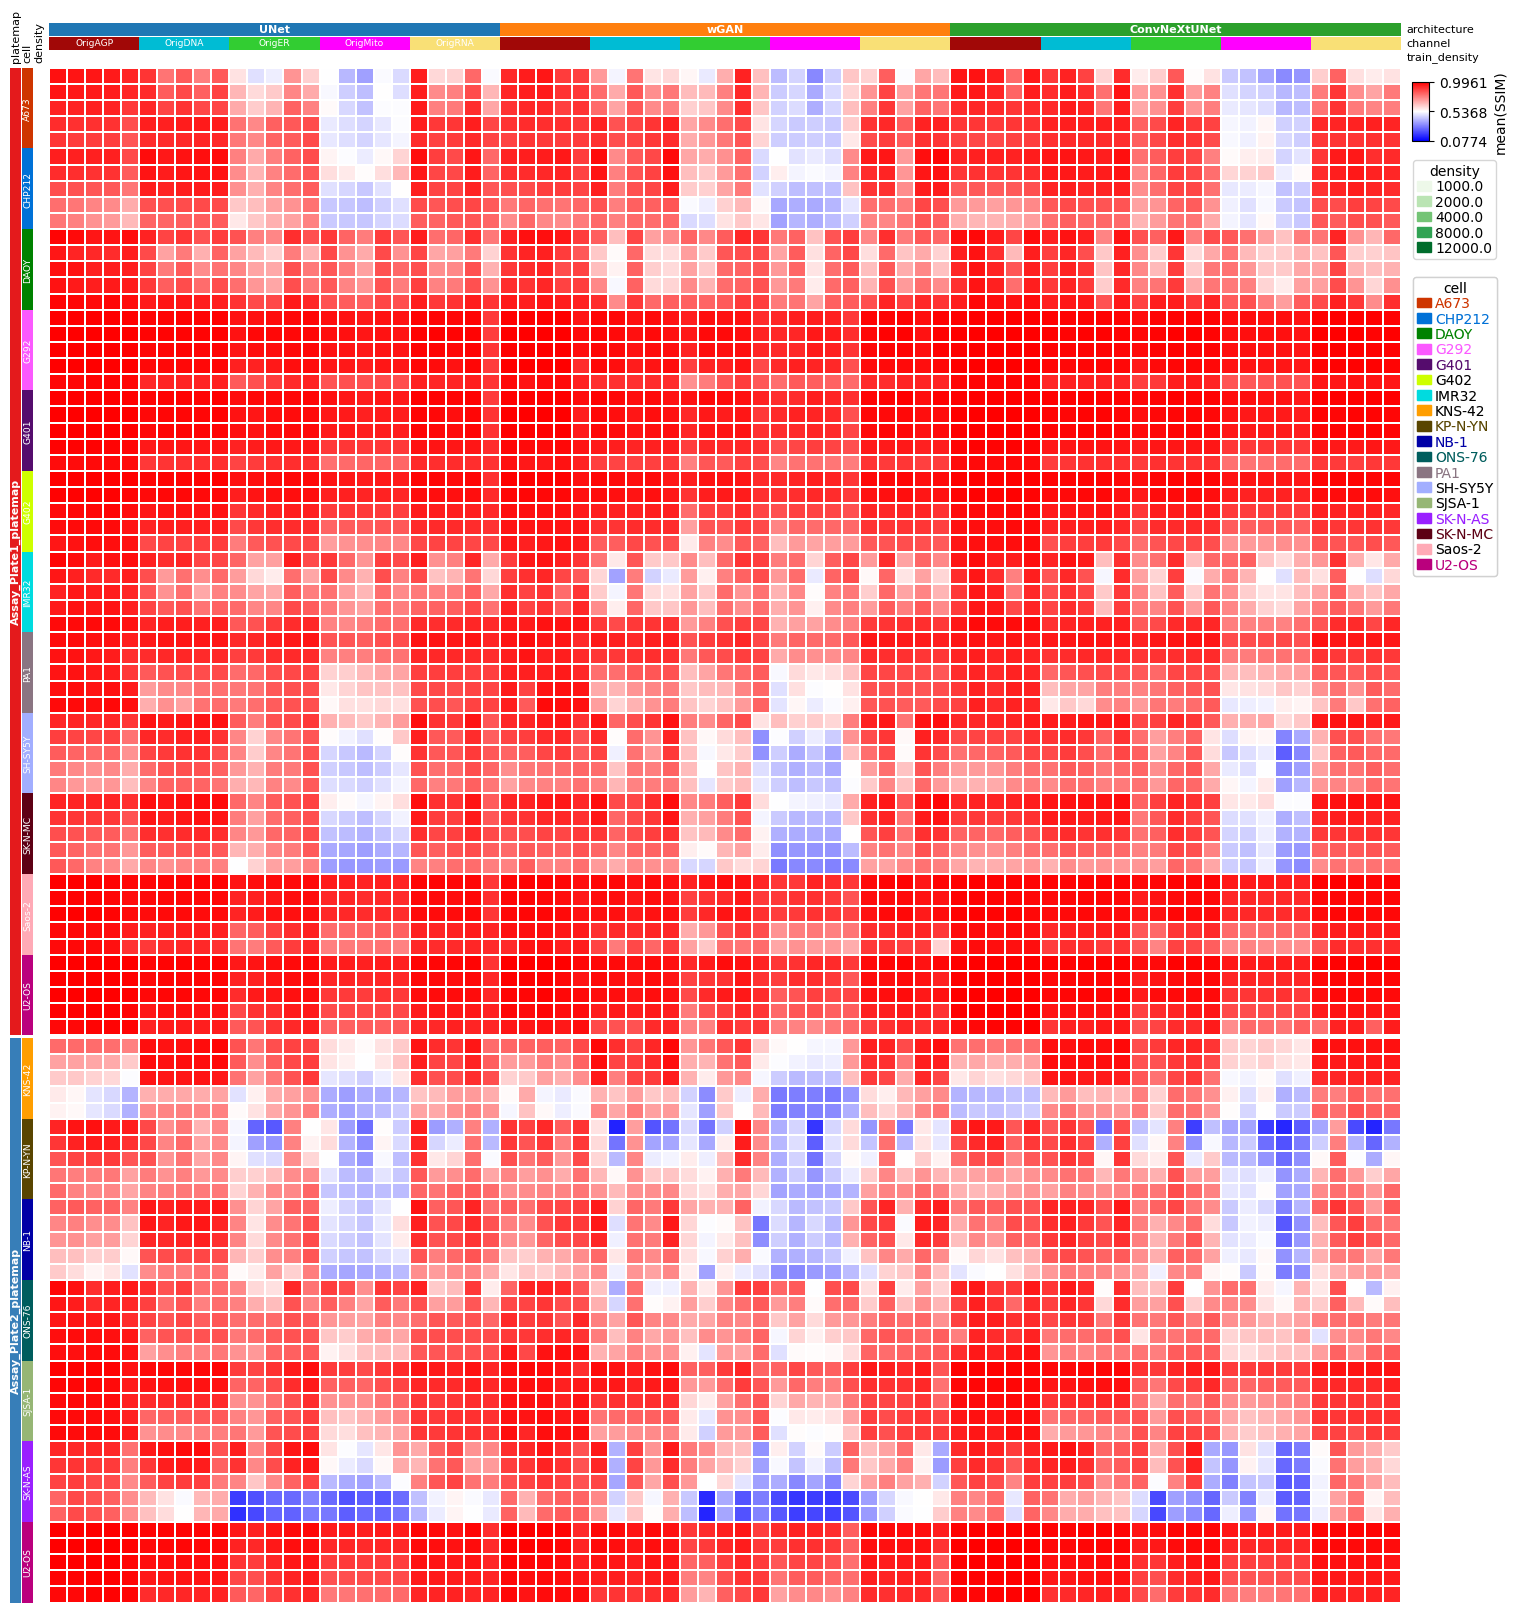

Plotting metric: foreground_ssim


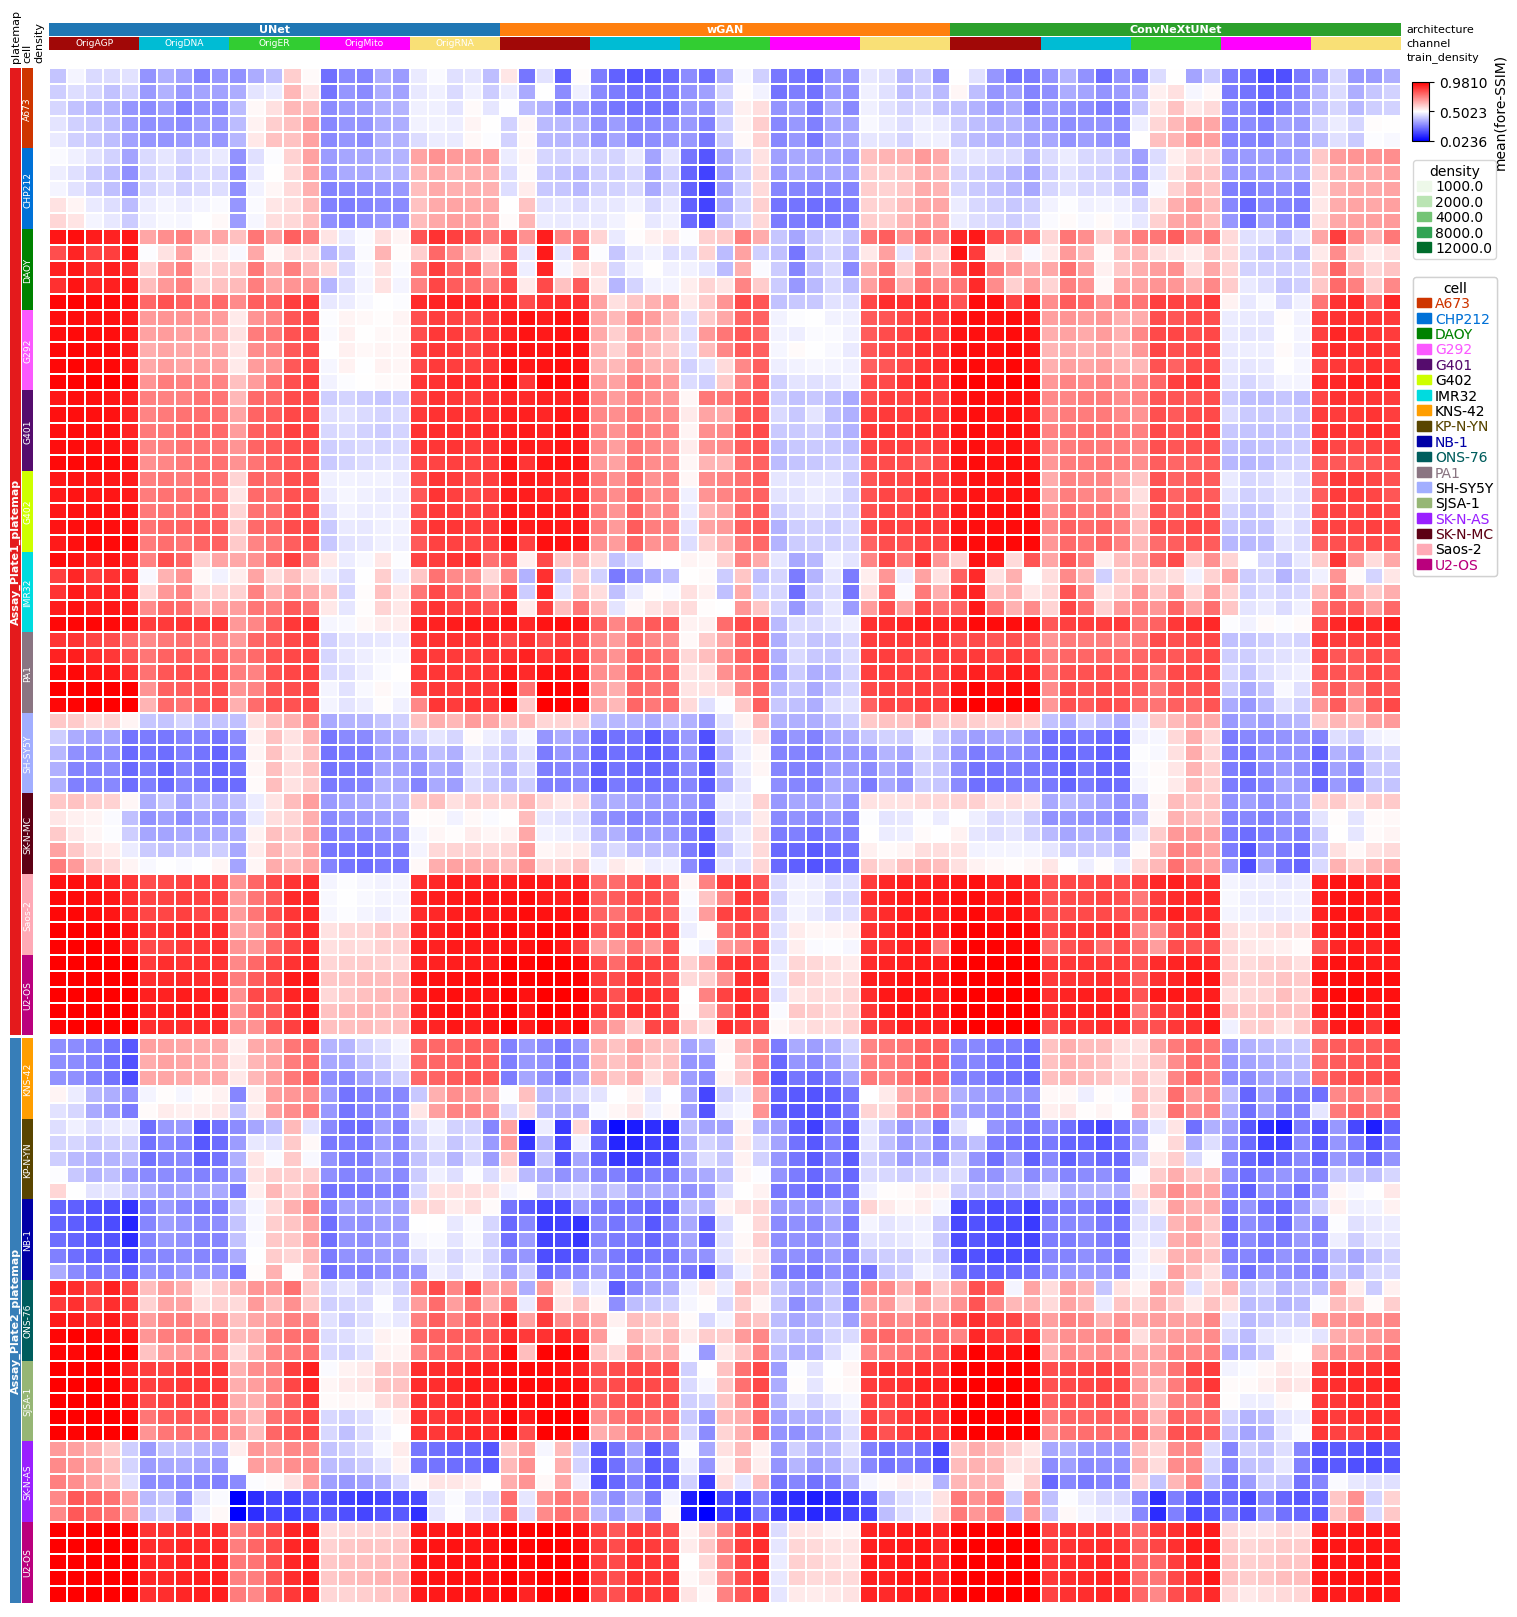

In [6]:
for metric_name, metric_config in model_eval_dict.items():

    if 'psnr' in metric_name.lower():
        # Temporarily skip because some PSNRs are infs due to half precision issues
        # re-running under full precision in progress and should fix the issue.
        # In the mean time skip psnr visualizations
        continue

    print(f"Plotting metric: {metric_name}")

    _df = eval_df.loc[
            eval_df['metric_name'] == metric_name
        ].copy()
    if metric_config['transform_fn'] is not None:
        _df['metric_value'] = _df['metric_value'].apply(metric_config['transform_fn'])

    with warnings.catch_warnings():
        # suppress pandas related future warning originating from PyComplexHeatmap
        warnings.simplefilter(action='ignore', category=FutureWarning)
        plot_dict = plot_cm_raw_metrics(
            _df,
            metric_config['name'],
            cell_palette=cell_palette,
            channel_palette=channel_palette,
            architecture_palette=architecture_palette,
            density_palette=density_palette,
        )

    plot_dict['fig'].savefig(PLOT_SUBDIR / f"{metric_name}_heatmap.png", dpi=330)